In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()



,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.shape

(5110, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
total_rows = df.shape[0]
total_columns = df.shape[1]

input_features = df.drop(columns=['id', 'stroke']).columns
target_feature = 'stroke'

print("Total data points:", total_rows)
print("Total columns:", total_columns)
print("Number of input features after removing id and target:", len(input_features))
print("Input features:", list(input_features))
print("Target feature:", target_feature)

Total data points: 5110
Total columns: 12
Number of input features after removing id and target: 10
Input features: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']
Target feature: stroke


In [ ]:
numerical_features = ['age', 'avg_glucose_level', 'bmi']
binary_numerical_features = ['hypertension', 'heart_disease']
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

print("Numerical features:", numerical_features)
print("Binary numerical features:", binary_numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'avg_glucose_level', 'bmi']
Binary numerical features: ['hypertension', 'heart_disease']
Categorical features: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [ ]:
for col in categorical_features:
    print(col)
    print(df[col].unique())
    print()

gender
['Male' 'Female' 'Other']

ever_married
['Yes' 'No']

work_type
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

Residence_type
['Urban' 'Rural']

smoking_status
['formerly smoked' 'never smoked' 'smokes' 'Unknown']



In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
df_corr = df.copy()

# Fill missing BMI values only for correlation analysis
df_corr['bmi'] = df_corr['bmi'].fillna(df_corr['bmi'].median())

# Encode categorical columns
le = LabelEncoder()

categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in categorical_features:
    df_corr[col] = le.fit_transform(df_corr[col])

# Drop id because it is only an identifier
df_corr = df_corr.drop(columns=['id'])

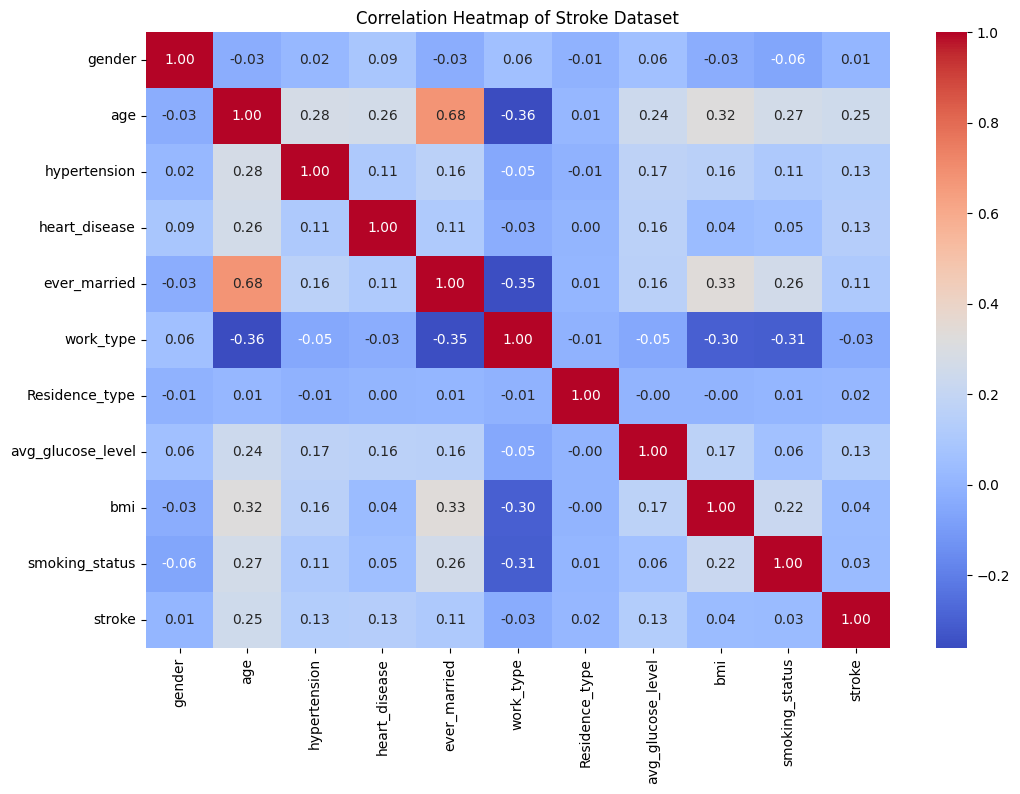

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Stroke Dataset")
plt.show()

In [ ]:
correlation_with_stroke = df_corr.corr()['stroke'].sort_values(ascending=False)
correlation_with_stroke

,stroke
stroke,1.000000
age,0.245257
heart_disease,0.134914
avg_glucose_level,0.131945
hypertension,0.127904
ever_married,0.108340
bmi,0.036110
smoking_status,0.028123
Residence_type,0.015458
gender,0.008929


In [ ]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [ ]:
df['stroke'].value_counts(normalize=True) * 100

,proportion
stroke,
0,95.127202
1,4.872798


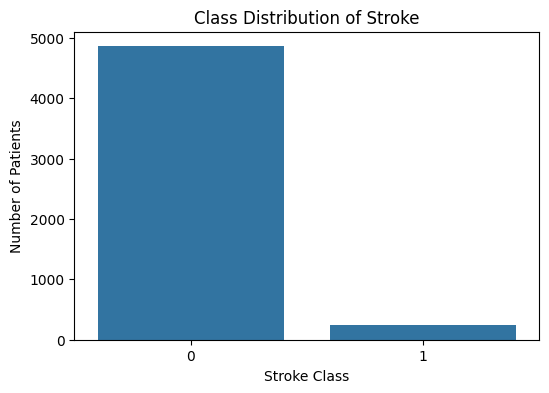

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='stroke', data=df)
plt.title("Class Distribution of Stroke")
plt.xlabel("Stroke Class")
plt.ylabel("Number of Patients")
plt.show()

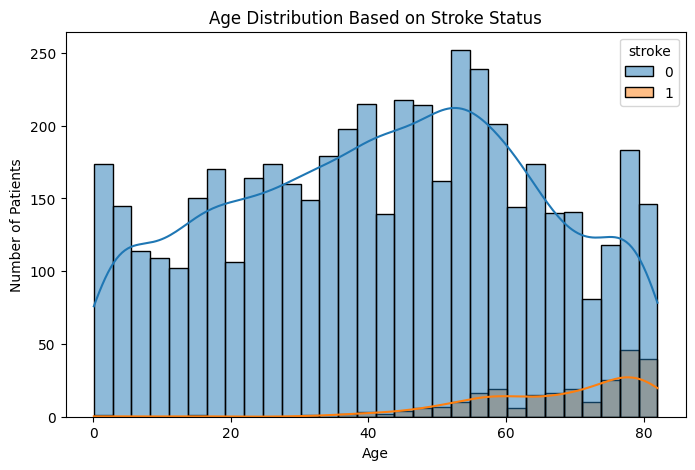

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='stroke', kde=True, bins=30)
plt.title("Age Distribution Based on Stroke Status")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

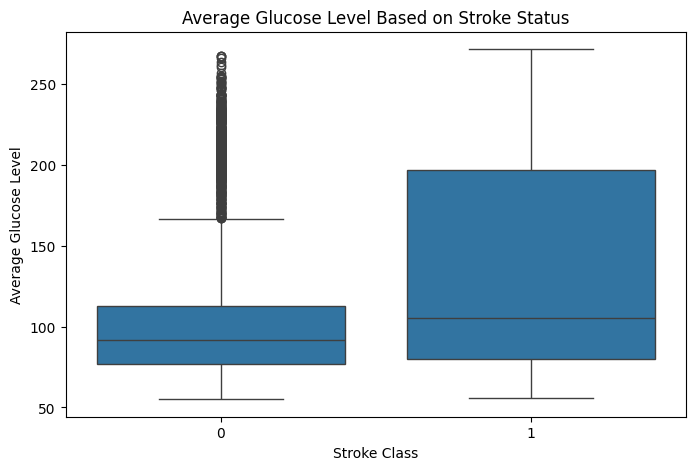

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)
plt.title("Average Glucose Level Based on Stroke Status")
plt.xlabel("Stroke Class")
plt.ylabel("Average Glucose Level")
plt.show()

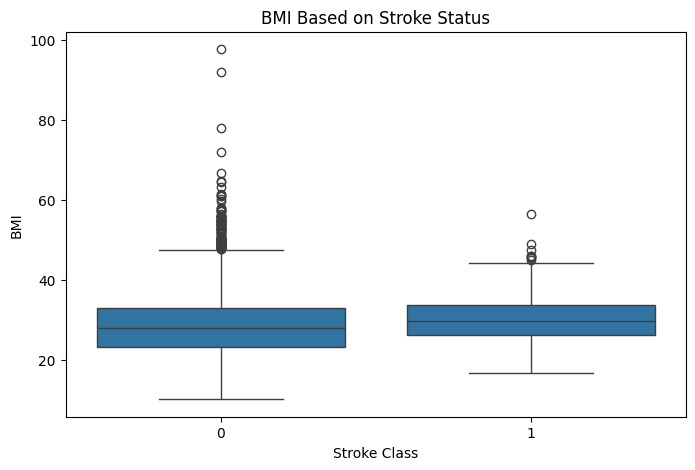

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='stroke', y='bmi', data=df)
plt.title("BMI Based on Stroke Status")
plt.xlabel("Stroke Class")
plt.ylabel("BMI")
plt.show()

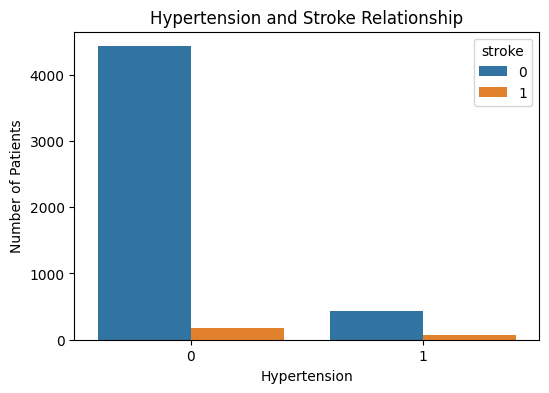

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='hypertension', hue='stroke', data=df)
plt.title("Hypertension and Stroke Relationship")
plt.xlabel("Hypertension")
plt.ylabel("Number of Patients")
plt.show()

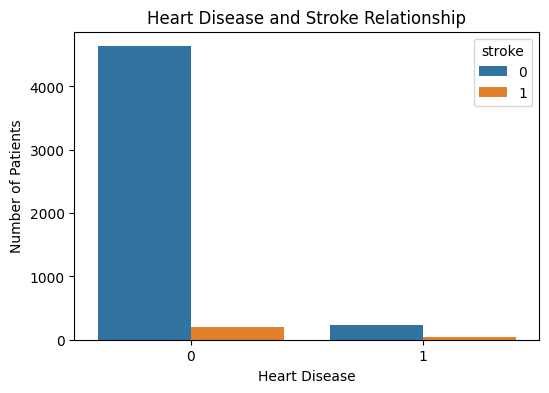

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='heart_disease', hue='stroke', data=df)
plt.title("Heart Disease and Stroke Relationship")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.show()

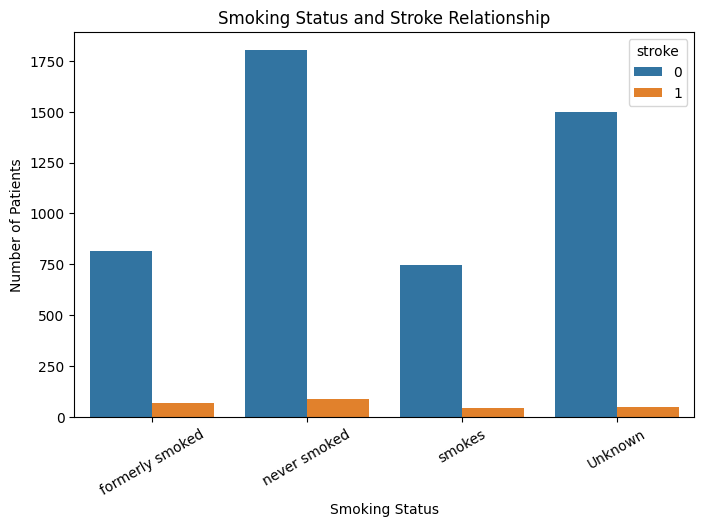

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='smoking_status', hue='stroke', data=df)
plt.title("Smoking Status and Stroke Relationship")
plt.xlabel("Smoking Status")
plt.ylabel("Number of Patients")
plt.xticks(rotation=30)
plt.show()

Data pre processing starts!

In [ ]:
df_processed = df.copy()

df_processed.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df_processed[['id']].head()


,id
0,9046
1,51676
2,31112
3,60182
4,1665


In [ ]:
df_processed = df_processed.drop(columns=['id'])

df_processed.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df_processed.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
imputer = SimpleImputer(strategy='median')

df_processed[['bmi']] = imputer.fit_transform(df_processed[['bmi']])

print("Median value used for BMI:", imputer.statistics_[0])

df_processed.isnull().sum()

Median value used for BMI: 28.1


,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [ ]:
categorical_columns = df_processed.select_dtypes(include=['object']).columns

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')


In [ ]:
for col in categorical_columns:
    print(col)
    print(df_processed[col].unique())
    print()

gender
['Male' 'Female' 'Other']

ever_married
['Yes' 'No']

work_type
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

Residence_type
['Urban' 'Rural']

smoking_status
['formerly smoked' 'never smoked' 'smokes' 'Unknown']



In [ ]:
try:
    encoder = OneHotEncoder(drop='first', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(drop='first', sparse=False)

encoded_data = encoder.fit_transform(df_processed[categorical_columns])

encoded_columns = encoder.get_feature_names_out(categorical_columns)

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoded_columns,
    index=df_processed.index
)

df_processed = df_processed.drop(columns=categorical_columns)

df_processed = pd.concat([df_processed, encoded_df], axis=1)

df_processed.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,61.0,0,0,202.21,28.1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,80.0,0,1,105.92,32.5,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,49.0,0,0,171.23,34.4,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,79.0,1,0,174.12,24.0,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             5110 non-null   float64
 1   hypertension                    5110 non-null   int64  
 2   heart_disease                   5110 non-null   int64  
 3   avg_glucose_level               5110 non-null   float64
 4   bmi                             5110 non-null   float64
 5   stroke                          5110 non-null   int64  
 6   gender_Male                     5110 non-null   float64
 7   gender_Other                    5110 non-null   float64
 8   ever_married_Yes                5110 non-null   float64
 9   work_type_Never_worked          5110 non-null   float64
 10  work_type_Private               5110 non-null   float64
 11  work_type_Self-employed         5110 non-null   float64
 12  work_type_children              51

In [ ]:
df_processed[['age', 'avg_glucose_level', 'bmi']].describe()

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,5110.000000
mean,43.226614,106.147677,28.862035
std,22.612647,45.283560,7.699562
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.800000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,32.800000
max,82.000000,271.740000,97.600000


In [ ]:
X = df_processed.drop(columns=['stroke'])
y = df_processed['stroke']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (5110, 16)
Shape of y: (5110,)


In [ ]:
features_to_scale = ['age', 'avg_glucose_level', 'bmi']

scaler = StandardScaler()

print("Features selected for scaling:", features_to_scale)

Features selected for scaling: ['age', 'avg_glucose_level', 'bmi']


In [ ]:
df_processed.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,61.0,0,0,202.21,28.1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,80.0,0,1,105.92,32.5,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,49.0,0,0,171.23,34.4,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,79.0,1,0,174.12,24.0,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df_processed.isnull().sum()

,0
age,0
hypertension,0
heart_disease,0
avg_glucose_level,0
bmi,0
stroke,0
gender_Male,0
gender_Other,0
ever_married_Yes,0
work_type_Never_worked,0


In [ ]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             5110 non-null   float64
 1   hypertension                    5110 non-null   int64  
 2   heart_disease                   5110 non-null   int64  
 3   avg_glucose_level               5110 non-null   float64
 4   bmi                             5110 non-null   float64
 5   stroke                          5110 non-null   int64  
 6   gender_Male                     5110 non-null   float64
 7   gender_Other                    5110 non-null   float64
 8   ever_married_Yes                5110 non-null   float64
 9   work_type_Never_worked          5110 non-null   float64
 10  work_type_Private               5110 non-null   float64
 11  work_type_Self-employed         5110 non-null   float64
 12  work_type_children              51

Dataset splitting


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4088, 16)
X_test shape: (1022, 16)
y_train shape: (4088,)
y_test shape: (1022,)


In [ ]:
print("Original target distribution:")
print(y.value_counts(normalize=True) * 100)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Original target distribution:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

Training target distribution:
stroke
0    95.132094
1     4.867906
Name: proportion, dtype: float64

Testing target distribution:
stroke
0    95.107632
1     4.892368
Name: proportion, dtype: float64


In [ ]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

In [ ]:
X_train_scaled.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
2051,-0.347972,0,0,-0.702666,-0.835056,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2065,-1.052353,0,0,-0.729577,-0.756441,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1201,0.136290,0,0,-0.464438,0.435895,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3918,1.016767,0,0,-0.006731,0.357280,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
449,-0.039805,0,0,-0.842956,0.291767,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
X_train_scaled[features_to_scale].describe()

,age,avg_glucose_level,bmi
count,4.088000e+03,4.088000e+03,4.088000e+03
mean,4.171484e-17,8.169156e-17,5.301261e-17
std,1.000122e+00,1.000122e+00,1.000122e+00
min,-1.885284e+00,-1.131256e+00,-2.289444e+00
25%,-7.882100e-01,-6.420612e-01,-6.647225e-01
50%,4.824271e-02,-3.170891e-01,-8.820851e-02
75%,7.966478e-01,1.759110e-01,5.145106e-01
max,1.721148e+00,3.646985e+00,8.284347e+00


Model training and testing


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
model_results = []

In [ ]:
#Neural network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [ ]:
# Convert data type for Neural Network
X_train_nn = X_train_scaled.astype('float32')
X_test_nn = X_test_scaled.astype('float32')

y_train_nn = y_train.astype('float32')
y_test_nn = y_test.astype('float32')

In [ ]:
# Build Neural Network model
# Compute class weights to handle imbalance
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(0.5255849832861919), np.int64(1): np.float64(10.271356783919598)}


In [ ]:
# Build Neural Network model
nn_model = Sequential()

nn_model.add(Dense(16, activation='relu', input_shape=(X_train_nn.shape[1],)))
nn_model.add(Dense(8, activation='relu'))
nn_model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile Neural Network model
nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [ ]:
# Show model summary
nn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train Neural Network model using class weights
history = nn_model.fit(
    X_train_nn,
    y_train_nn,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4043 - loss: 0.6633 - precision: 0.0611 - recall: 0.8224 - val_accuracy: 0.7188 - val_loss: 0.6225 - val_precision: 0.1355 - val_recall: 0.7234
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6988 - loss: 0.5790 - precision: 0.1111 - recall: 0.7829 - val_accuracy: 0.7396 - val_loss: 0.5559 - val_precision: 0.1542 - val_recall: 0.7872
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7278 - loss: 0.5294 - precision: 0.1211 - recall: 0.7763 - val_accuracy: 0.6822 - val_loss: 0.5754 - val_precision: 0.1340 - val_recall: 0.8298
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7223 - loss: 0.4954 - precision: 0.1228 - recall: 0.8092 - val_accuracy: 0.7176 - val_loss: 0.5185 - val_precision: 0.1489 - val_recall: 0.8298
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7251 - loss: 0.4761 - precision: 0.1276 - recall: 0.8421 - val_accuracy: 0.6968 - val_loss: 

In [ ]:
# Test Neural Network model
nn_prob = nn_model.predict(X_test_nn)

nn_pred = (nn_prob > 0.5).astype(int).reshape(-1)

nn_accuracy = accuracy_score(y_test, nn_pred)
nn_precision = precision_score(y_test, nn_pred, zero_division=0)
nn_recall = recall_score(y_test, nn_pred, zero_division=0)
nn_f1 = f1_score(y_test, nn_pred, zero_division=0)

print("Neural Network Results")
print("Accuracy:", nn_accuracy)
print("Precision:", nn_precision)
print("Recall:", nn_recall)
print("F1-score:", nn_f1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Neural Network Results
Accuracy: 0.7299412915851272
Precision: 0.12582781456953643
Recall: 0.76
F1-score: 0.2159090909090909


In [ ]:
model_results.append({
    "Model": "Neural Network",
    "Accuracy": nn_accuracy,
    "Precision": nn_precision,
    "Recall": nn_recall,
    "F1-score": nn_f1
})

In [ ]:
# Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=1,
    class_weight='balanced'
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Predict on test data
logistic_pred = logistic_model.predict(X_test_scaled)

# Predict probabilities for ROC/AUC later
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(y_test, logistic_pred, zero_division=0)
logistic_recall = recall_score(y_test, logistic_pred, zero_division=0)
logistic_f1 = f1_score(y_test, logistic_pred, zero_division=0)

print("Logistic Regression Results")
print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1-score:", logistic_f1)


Logistic Regression Results
Accuracy: 0.7377690802348337
Precision: 0.1267123287671233
Recall: 0.74
F1-score: 0.21637426900584794


In [ ]:
model_results.append({
    "Model": "Logistic Regression",
    "Accuracy": logistic_accuracy,
    "Precision": logistic_precision,
    "Recall": logistic_recall,
    "F1-score": logistic_f1
})

In [ ]:
# K-Nearest Neighbors model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Predict on test data
knn_pred = knn_model.predict(X_test_scaled)

# Predict probabilities for ROC/AUC later
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, zero_division=0)
knn_recall = recall_score(y_test, knn_pred, zero_division=0)
knn_f1 = f1_score(y_test, knn_pred, zero_division=0)

print("KNN Results")
print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1-score:", knn_f1)

KNN Results
Accuracy: 0.9461839530332681
Precision: 0.0
Recall: 0.0
F1-score: 0.0


In [ ]:
model_results.append({
    "Model": "KNN",
    "Accuracy": knn_accuracy,
    "Precision": knn_precision,
    "Recall": knn_recall,
    "F1-score": knn_f1
})

In [ ]:
# Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train_scaled, y_train)

# Predict on test data
nb_pred = nb_model.predict(X_test_scaled)

# Predict probabilities for ROC/AUC later
nb_prob = nb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred, zero_division=0)
nb_recall = recall_score(y_test, nb_pred, zero_division=0)
nb_f1 = f1_score(y_test, nb_pred, zero_division=0)

print("Naive Bayes Results")
print("Accuracy:", nb_accuracy)
print("Precision:", nb_precision)
print("Recall:", nb_recall)
print("F1-score:", nb_f1)

Naive Bayes Results
Accuracy: 0.18395303326810175
Precision: 0.05656108597285068
Recall: 1.0
F1-score: 0.10706638115631692


In [ ]:
model_results.append({
    "Model": "Naive Bayes",
    "Accuracy": nb_accuracy,
    "Precision": nb_precision,
    "Recall": nb_recall,
    "F1-score": nb_f1
})

In [ ]:

results_df = pd.DataFrame(final_results)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,Neural Network,0.7299,0.1258,0.76,0.2159
1,Logistic Regression,0.7378,0.1267,0.74,0.2164
2,KNN,0.9462,0.0000,0.00,0.0000
3,Naive Bayes,0.1840,0.0566,1.00,0.1071


unsupervised


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
X_kmeans = X_train_scaled.copy()

print("Shape of K-Means input data:", X_kmeans.shape)

Shape of K-Means input data: (4088, 16)


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=1, n_init=10)

kmeans.fit(X_kmeans)

cluster_labels = kmeans.labels_

print("Cluster labels:")
print(cluster_labels)

print("Cluster counts:")
print(pd.Series(cluster_labels).value_counts())

Cluster labels:
[0 0 1 ... 0 1 0]
Cluster counts:
1    2614
0    1474
Name: count, dtype: int64


In [ ]:
silhouette = silhouette_score(X_kmeans, cluster_labels)
dbi = davies_bouldin_score(X_kmeans, cluster_labels)

print("Silhouette Score:", silhouette)
print("Davies-Bouldin Index:", dbi)

Silhouette Score: 0.20265443573575484
Davies-Bouldin Index: 1.6332247176927135


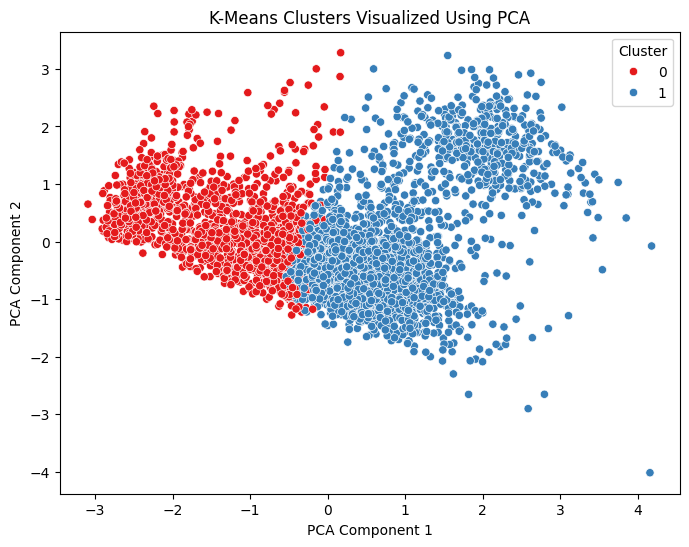

In [ ]:
pca = PCA(n_components=2, random_state=1)

X_pca = pca.fit_transform(X_kmeans)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_labels,
    palette='Set1'
)

plt.title("K-Means Clusters Visualized Using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

In [ ]:
cluster_analysis = pd.DataFrame({
    "Cluster": cluster_labels,
    "Actual Stroke": y_train.values
})

pd.crosstab(cluster_analysis["Cluster"], cluster_analysis["Actual Stroke"])

Actual Stroke,0,1
Cluster,,
0,1471,3
1,2418,196


Model evaluation


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
final_results = [
    {
        "Model": "Neural Network",
        "Accuracy": nn_accuracy,
        "Precision": nn_precision,
        "Recall": nn_recall,
        "F1-score": nn_f1
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1-score": logistic_f1
    },
    {
        "Model": "KNN",
        "Accuracy": knn_accuracy,
        "Precision": knn_precision,
        "Recall": knn_recall,
        "F1-score": knn_f1
    },
    {
        "Model": "Naive Bayes",
        "Accuracy": nb_accuracy,
        "Precision": nb_precision,
        "Recall": nb_recall,
        "F1-score": nb_f1
    }
]

results_df = pd.DataFrame(final_results)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,Neural Network,0.7299,0.1258,0.76,0.2159
1,Logistic Regression,0.7378,0.1267,0.74,0.2164
2,KNN,0.9462,0.0000,0.00,0.0000
3,Naive Bayes,0.1840,0.0566,1.00,0.1071


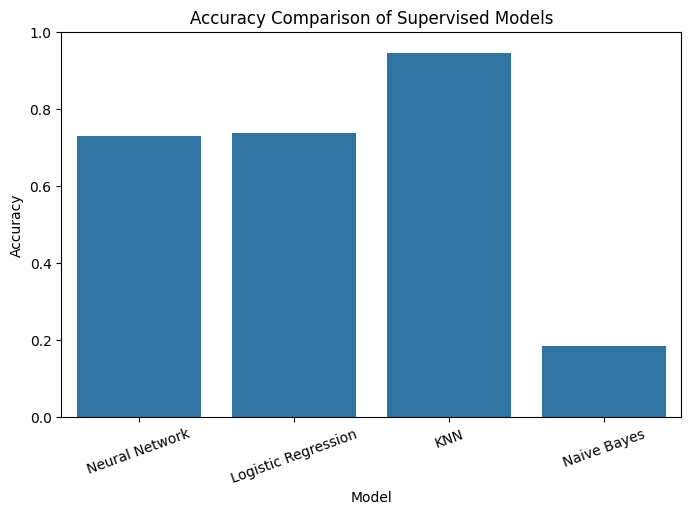

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.title("Accuracy Comparison of Supervised Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

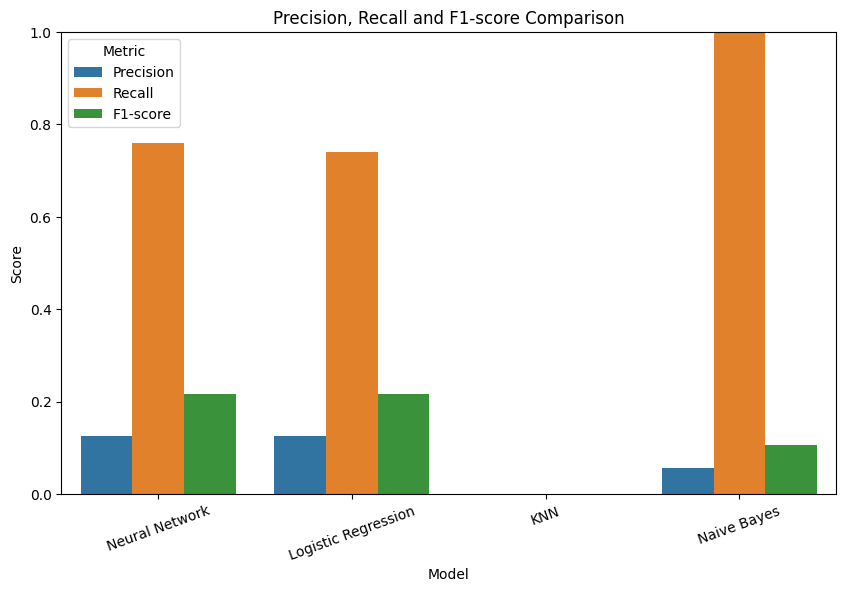

In [ ]:
metrics_df = results_df.melt(
    id_vars="Model",
    value_vars=["Precision", "Recall", "F1-score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x="Model",
    y="Score",
    hue="Metric",
    data=metrics_df
)

plt.title("Precision, Recall and F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.show()

In [ ]:
model_predictions = {
    "Neural Network": nn_pred,
    "Logistic Regression": logistic_pred,
    "KNN": knn_pred,
    "Naive Bayes": nb_pred
}

model_probabilities = {
    "Neural Network": nn_prob.reshape(-1),
    "Logistic Regression": logistic_prob,
    "KNN": knn_prob,
    "Naive Bayes": nb_prob
}

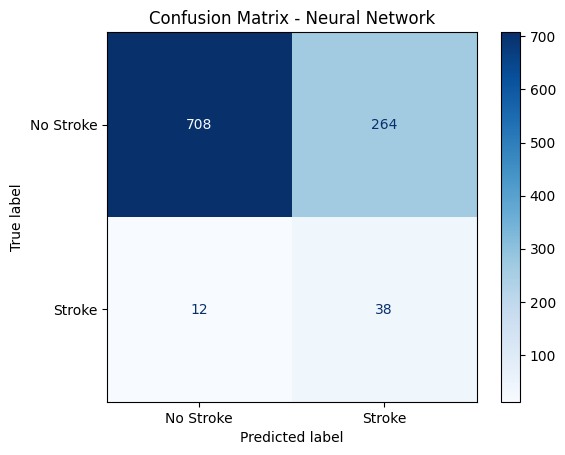

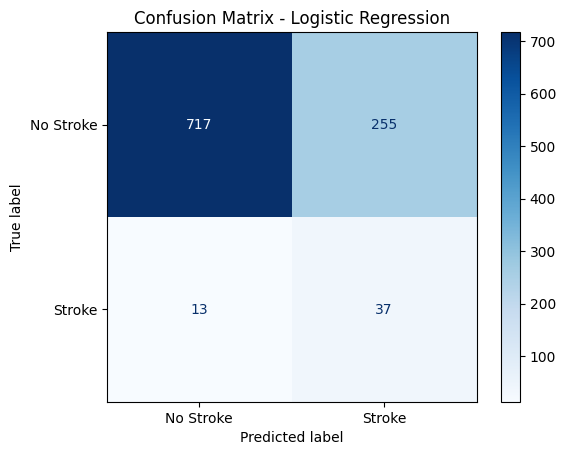

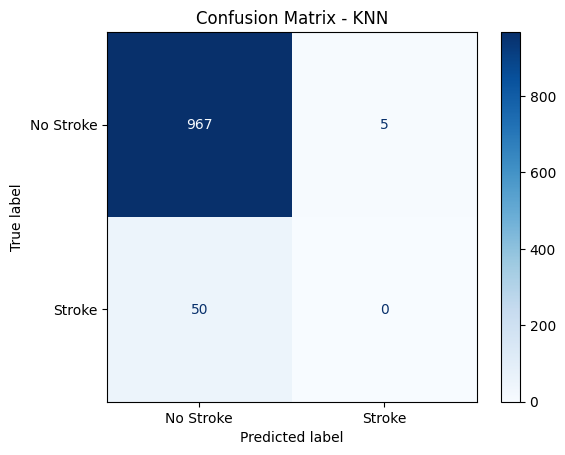

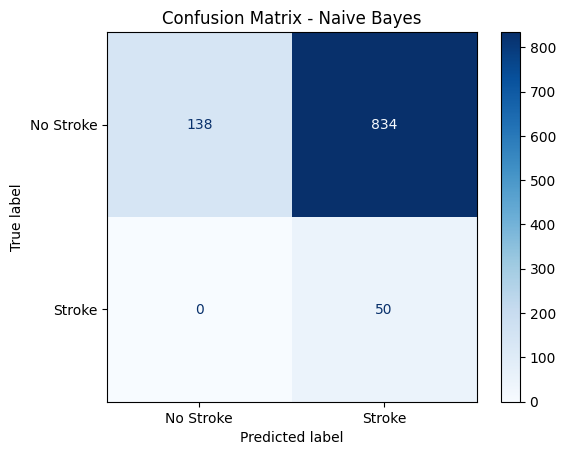

In [ ]:
for model_name, prediction in model_predictions.items():
    cm = confusion_matrix(y_test, prediction)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Stroke", "Stroke"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

In [ ]:
for model_name, prediction in model_predictions.items():
    print(model_name)
    print(classification_report(
        y_test,
        prediction,
        target_names=["No Stroke", "Stroke"],
        zero_division=0
    ))
    print("-" * 60)

Neural Network
              precision    recall  f1-score   support

   No Stroke       0.98      0.73      0.84       972
      Stroke       0.13      0.76      0.22        50

    accuracy                           0.73      1022
   macro avg       0.55      0.74      0.53      1022
weighted avg       0.94      0.73      0.81      1022

------------------------------------------------------------
Logistic Regression
              precision    recall  f1-score   support

   No Stroke       0.98      0.74      0.84       972
      Stroke       0.13      0.74      0.22        50

    accuracy                           0.74      1022
   macro avg       0.55      0.74      0.53      1022
weighted avg       0.94      0.74      0.81      1022

------------------------------------------------------------
KNN
              precision    recall  f1-score   support

   No Stroke       0.95      0.99      0.97       972
      Stroke       0.00      0.00      0.00        50

    accuracy         

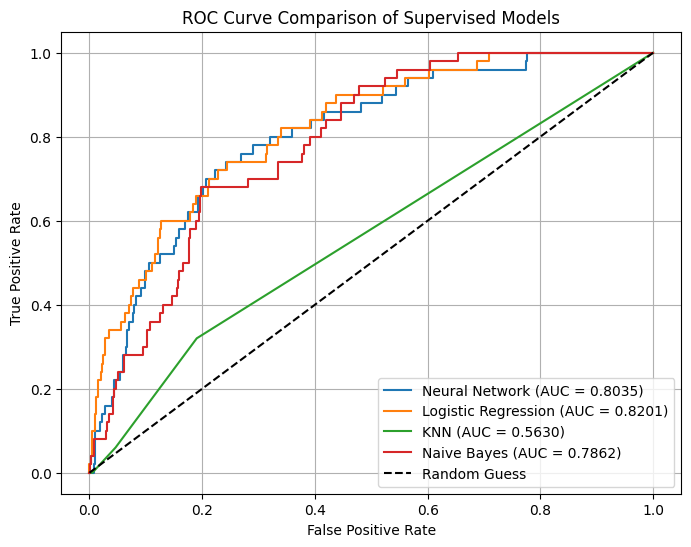

In [ ]:
plt.figure(figsize=(8, 6))

auc_scores = {}

for model_name, probability in model_probabilities.items():
    fpr, tpr, thresholds = roc_curve(y_test, probability)
    roc_auc = auc(fpr, tpr)
    auc_scores[model_name] = roc_auc

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Supervised Models")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [ ]:
auc_df = pd.DataFrame({
    "Model": list(auc_scores.keys()),
    "AUC Score": list(auc_scores.values())
})

auc_df.round(4)

,Model,AUC Score
0,Neural Network,0.8035
1,Logistic Regression,0.8201
2,KNN,0.5630
3,Naive Bayes,0.7862


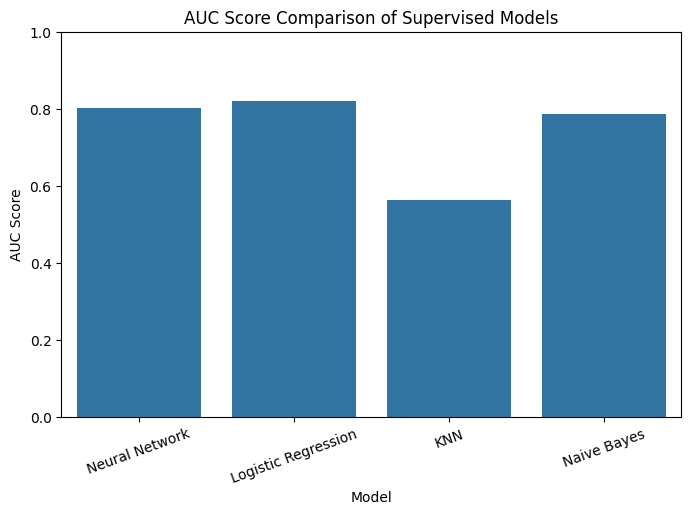

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="Model",
    y="AUC Score",
    data=auc_df
)

plt.title("AUC Score Comparison of Supervised Models")
plt.xlabel("Model")
plt.ylabel("AUC Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()